In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from helper_functions import sample_data_with_optional_balancing

In [7]:
data=(r"G:\SP8_FLIM\old_from_sorted\Tables_unsorted\all_merged_csv_files\n5-all-young.csv")
data2=(r"G:\SP8_FLIM\old_from_sorted\Tables_unsorted\all_merged_csv_files\n6,5-all-old.csv")

df= pd.read_csv(data)#,sep=",")
df2= pd.read_csv(data2)#,sep=",")

#combined_df= pd.read_csv(output_path)#,sep=",")
#Concatenate the DataFrames
combined_df = pd.concat([df, df2], ignore_index=True)

# # Optional: Check the combined DataFrame
# print(combined_df.head())

# # Save the combined DataFrame if needed
# output_path = r"G:\SP8_FLIM\sMol_experiment\Avcute\Outputs\combined_master_table.csv"
# combined_df.to_csv(output_path, index=False)

# print(f"Combined DataFrame saved to {output_path}")

In [8]:
combined_df

,Label,Area,intensity,chi,tau,int_min,chi_min,tau_min,int_std,chi_std,tau_std,Condition,Treatment,Time,Segmentation,Date
0,1,107.0,310.887850,98.130841,1005.495327,232.0,65.0,559.0,49.267025,12.194747,210.710608,cl1,no,4-6h,OW,12.10.2023
1,3,57.0,427.578947,105.701754,1041.842105,359.0,79.0,643.0,34.999222,12.540412,216.532708,cl1,no,4-6h,OW,12.10.2023
2,4,33.0,307.515152,96.303030,997.151515,248.0,74.0,602.0,44.330112,12.976634,245.507405,cl1,no,4-6h,OW,12.10.2023
3,5,65.0,436.938462,104.800000,955.138462,324.0,83.0,620.0,59.369217,11.500100,189.276751,cl1,no,4-6h,OW,12.10.2023
4,6,61.0,447.098361,103.901639,987.114754,393.0,79.0,546.0,34.210872,10.710352,203.856676,cl1,no,4-6h,OW,12.10.2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1875,7,81.0,385.333333,99.320988,882.407407,299.0,72.0,497.0,45.128896,13.434640,172.985604,wt,no,24-28h,OW,27.11.2023
1876,8,39.0,477.307692,104.256410,837.128205,434.0,78.0,529.0,25.734496,12.067583,155.858118,wt,no,24-28h,OW,27.11.2023
1877,9,47.0,500.127660,105.234043,854.085106,367.0,79.0,575.0,69.286214,12.864619,124.017300,wt,no,24-28h,OW,27.11.2023
1878,10,56.0,450.928571,102.303571,900.982143,417.0,73.0,504.0,16.947247,13.357608,185.431590,wt,no,24-28h,OW,27.11.2023


In [9]:
def sample_data_with_optional_balancing(data, n=100, balance_by_date=False, group_columns=None, extra_group_column=None):
    import numpy as np
    import pandas as pd

    """
    Sample `n` instances for each combination of specified grouping columns.
    Optionally balance the sampling by `Date` if `balance_by_date` is True. Logs cases where
    fewer than `n` instances are available.

    Args:
    - data: DataFrame containing the data to sample from.
    - n: Number of instances to sample for each group combination.
    - balance_by_date: Boolean flag indicating whether to balance samples by `Date` (default: False).
    - group_columns: List of column names to group by (default: ['transfection', 'cells', 'treatment']).
    - extra_group_column: An additional column to include in the grouping (e.g., 'treat_type').

    Returns:
    - A tuple: (sampled_data, shortfall_log)
      sampled_data: A DataFrame with the sampled data.
      shortfall_log: A DataFrame logging groups where fewer than `n` instances were available.
    """
    
    # Set default grouping columns if not provided
    if group_columns is None:
        group_columns = ['transfection', 'cells', 'treatment']
    
    # Add the extra grouping column if specified
    if extra_group_column and extra_group_column in data.columns:
        group_columns.append(extra_group_column)

    # Group the data by the specified columns
    grouped_data = data.groupby(group_columns)

    sampled_data = pd.DataFrame()
    shortfall_log = []

    # Iterate over each group
    for group_name, group_df in grouped_data:
        total_available = len(group_df)

        # If the group has fewer than `n` instances, log the shortfall
        if total_available < n:
            shortfall_log.append({
                'group': group_name,
                'available_instances': total_available,
                'requested_samples': n
            })
            sampled_group_df = group_df
        else:
            group_df = group_df.sample(frac=1, random_state=42)

            if balance_by_date and 'Date' in group_df.columns:
                date_counts = group_df['Date'].value_counts()
                samples_per_date = (date_counts / date_counts.sum() * n).astype(int)
                sampled_group_df = pd.DataFrame()

                for date, count in samples_per_date.items():
                    available_from_date = len(group_df[group_df['Date'] == date])
                    samples_to_take = min(count, available_from_date)
                    sampled_group_df = pd.concat([
                        sampled_group_df,
                        group_df[group_df['Date'] == date].sample(samples_to_take, replace=False)
                    ])

                if len(sampled_group_df) < n:
                    additional_samples = group_df[~group_df.index.isin(sampled_group_df.index)].sample(n - len(sampled_group_df), replace=False)
                    sampled_group_df = pd.concat([sampled_group_df, additional_samples])
                elif len(sampled_group_df) > n:
                    sampled_group_df = sampled_group_df.sample(n=n, replace=False)
            else:
                sampled_group_df = group_df.sample(n=n, replace=False, random_state=42)

        sampled_data = pd.concat([sampled_data, sampled_group_df], ignore_index=True)

    # Convert the shortfall log to a DataFrame
    shortfall_log_df = pd.DataFrame(shortfall_log)

    # Inspect the shortfall log
    if not shortfall_log_df.empty:
        print("Groups with fewer available instances than requested:")
        print(shortfall_log_df)
    else:
        print("No shortfalls found!")

    return sampled_data, shortfall_log_df


In [11]:
sampled_data, shortfall_log = sample_data_with_optional_balancing(
    data=combined_df, n=100, group_columns = ['Condition', 'Time']
)


No shortfalls found!


In [12]:
sampled_data

,Label,Area,intensity,chi,tau,int_min,chi_min,tau_min,int_std,chi_std,tau_std,Condition,Treatment,Time,Segmentation,Date
0,19,44.0,309.909091,97.772727,1325.477273,236.0,77.0,663.0,38.859197,12.486108,343.421388,cl1,no,24-28h,OW,13.10.2023
1,7,49.0,341.306122,99.122449,1286.489796,292.0,75.0,689.0,36.597203,9.747072,288.132490,cl1,no,24-28h,OW,13.10.2023
2,36,46.0,509.282609,110.695652,900.130435,453.0,84.0,585.0,26.594919,14.876111,173.679191,cl1,no,24-28h,OW,30.11.2023
3,35,78.0,474.448718,110.294872,928.282051,430.0,78.0,525.0,15.818398,13.796236,168.521923,cl1,no,24-28h,OW,30.11.2023
4,6,62.0,486.822581,109.693548,1330.145161,431.0,83.0,833.0,21.913705,12.984592,265.046183,cl1,no,24-28h,OW,11.09.2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,2,129.0,516.410853,105.775194,894.782946,282.0,70.0,543.0,114.965557,14.827818,172.488623,wt,no,4-6h,OW,22.11.2023
596,6,181.0,465.519337,106.464088,837.055249,319.0,68.0,464.0,90.187563,14.155610,170.225775,wt,no,4-6h,OW,22.11.2023
597,4,71.0,399.760563,103.338028,996.070423,331.0,76.0,531.0,45.535148,12.025728,199.557138,wt,no,4-6h,OW,12.10.2023
598,8,107.0,434.663551,100.037383,997.149533,389.0,60.0,595.0,30.841453,12.972239,226.920209,wt,no,4-6h,OW,01.11.2023


In [51]:
import pandas as pd

# Load your dataset (replace 'your_data.csv' with your actual filename)
# Filter for transfection == "vmat"
filtered_df = combined_df[combined_df["transfection"] == "vmat"]

# Grouping by "treatment" and "cells" and calculating the median for pH and lifetime data
median_values = filtered_df.groupby(["treatment", "cells"])[["predicted_pH_values", "mean_tau"]].median().reset_index()


# Grouping by "treatment" and "cells" and calculating the median for pH and lifetime data
median_values = combined_df.groupby(["treatment", "cells"])[["predicted_pH_values", "mean_tau"]].median().reset_index()

# Display the results
print(median_values)


# # Save the DataFrame back to CSV with the new column
output_path = r"C:\Users\med\Desktop\Thesis\For_Fig\Python plots\median_pH_lifetime_results.xlsx"
median_values.to_excel(output_path, index=False)

       treatment cells  predicted_pH_values     mean_tau
0        5HTP100   cl1             5.758089  1033.020833
1        5HTP100   cl2             5.460416   960.581081
2       LDOPA100   cl1             5.602476   991.456000
3       LDOPA100   cl2             5.568904   983.559019
4             NT   cl1             5.370936   944.414121
..           ...   ...                  ...          ...
61  pro-Acute100   cl2             6.077001  1140.761905
62   pro-Acute50   cl1             6.011218  1116.596154
63   pro-Acute50   cl2             6.085304  1143.858985
64           res   cl1             5.478438   964.135135
65           res   cl2             5.379918   945.929091

[66 rows x 4 columns]


In [52]:
import pandas as pd

# Load your dataset
df =  combined_df # Replace with your actual file path

# Filter for specific treatments
filtered_df = df[df["treatment"].isin(["NT", "5HTP100", "LDOPA100"])]

# Select relevant columns
filtered_df = filtered_df[["Date", "File Name", "mean_tau", "predicted_pH_values", "cells", "transfection", "treatment"]]

# Compute the median for each date, file name, cell type, transfection, and treatment
result = filtered_df.groupby(["Date", "File Name", "cells", "transfection", "treatment"]).agg(
    {"mean_tau": "median", "predicted_pH_values": "median"}
).reset_index()

result

,Date,File Name,cells,transfection,treatment,mean_tau,predicted_pH_values
0,2024_09_01,1f,cl1,pcdna,5HTP100,1198.456098,6.229223
1,2024_09_01,1f,cl1,pcdna,NT,1037.382886,5.772845
2,2024_09_01,1f,cl1,vmat,5HTP100,1248.391638,6.361318
3,2024_09_01,1f,cl1,vmat,NT,1069.642857,5.875662
4,2024_09_01,2f,cl1,pcdna,5HTP100,1386.085342,6.792936
...,...,...,...,...,...,...,...
180,2024_10_20,4f,cl1,vmat,NT,795.180000,5.000000
181,2024_10_20,5f,cl1,pcdna,LDOPA100,946.390739,5.380301
182,2024_10_20,5f,cl1,pcdna,NT,939.085366,5.338182
183,2024_10_20,5f,cl1,vmat,LDOPA100,1087.285723,5.928103


In [53]:

# Compute the median for each group
median_results = result.groupby(["cells", "transfection", "treatment"]).agg(
    median_tau=("mean_tau", "median"),
    median_pH=("predicted_pH_values", "median")
).reset_index()
median_results

,cells,transfection,treatment,median_tau,median_pH
0,cl1,pcdna,5HTP100,975.028571,5.530696
1,cl1,pcdna,LDOPA100,946.390739,5.380301
2,cl1,pcdna,NT,929.280169,5.269567
3,cl1,vmat,5HTP100,1133.950350,6.058591
4,cl1,vmat,LDOPA100,1087.524590,5.928832
5,cl1,vmat,NT,983.893763,5.550067
6,cl2,pcdna,5HTP100,896.631994,5.049758
7,cl2,pcdna,LDOPA100,942.251261,5.357866
8,cl2,pcdna,NT,939.427434,5.340301
9,cl2,vmat,5HTP100,1026.054393,5.733992


In [63]:
# # Save the DataFrame back to CSV with the new column
output_path = r"C:\Users\med\Desktop\Thesis\For_Fig\Python plots\nt-da-5ht.csv"
result.to_csv(output_path, index=False)

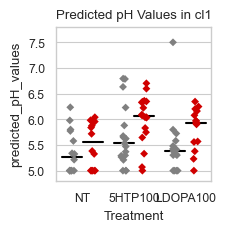

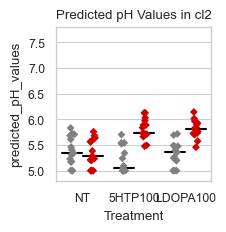

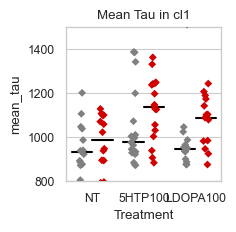

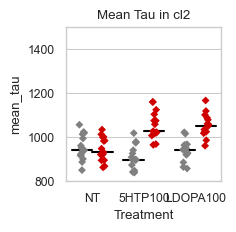

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define output directory for saving figures

# Define the directory where you want to save the figures
save_dir = r"C:\Users\med\Desktop\Thesis\For_Fig\Python plots"  # Change this to your desired path

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Define a custom color palette
custom_palette = {"pcdna": "#808080", "vmat": "#D00000"}

# Define treatment order
treatment_order = ["NT", "5HTP100", "LDOPA100"]  # Your desired order

# Determine global min & max for each y_value across both cell types
def get_global_ylim(data, y_value):
    return data[y_value].min(), data[y_value].max()

# Define common plotting function
def plot_stripplot(data, y_value, title, filename, global_ylim):
    plt.figure(figsize=(2, 2))

    # Boxplot for median line (hide everything else)
    sns.boxplot(
        data=data,
        x="treatment",
        y=y_value,
        order=treatment_order,
        hue="transfection",
        showfliers=False,  # Hide outliers
        showcaps=False,  # Hide caps
        whiskerprops={'visible': False},  # Hide whiskers
        boxprops={'visible': False},  # Hide box
        medianprops={"color": "black", "linewidth": 1.5},  # Show only median line
    )

    # Stripplot for individual points
    sns.stripplot(
        data=data,
        x="treatment",
        y=y_value,
        hue="transfection",
        dodge=True,  # Separate points within the same treatment category
        jitter=True,
        marker="D",
        s=4,  # Adjust dot size
        palette=custom_palette,
        order=treatment_order
    )

    plt.xlabel("Treatment")
    plt.ylabel(y_value)
    plt.title(title)
    plt.legend().remove()  # Remove legend
    plt.ylim(global_ylim)  # Set consistent y-axis limits across both cell types

    # Save plot
    filepath = os.path.join(save_dir, f"{filename}.svg")
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.show()

# Get global y-axis limits for consistency
ph_ylim = get_global_ylim(result, "predicted_pH_values")
tau_ylim = get_global_ylim(result, "mean_tau")

# Plot for cl1 & cl2 with the same y-axis scale
plot_stripplot(result[result["cells"] == "cl1"], "predicted_pH_values", "Predicted pH Values in cl1", "cl1_predicted_pH", (4.8,7.8))
plot_stripplot(result[result["cells"] == "cl2"], "predicted_pH_values", "Predicted pH Values in cl2", "cl2_predicted_pH", (4.8,7.8))

plot_stripplot(result[result["cells"] == "cl1"], "mean_tau", "Mean Tau in cl1", "cl1_mean_tau", (800,1500))
plot_stripplot(result[result["cells"] == "cl2"], "mean_tau", "Mean Tau in cl2", "cl2_mean_tau", (800,1500))


In [89]:
import os

# Define the directory where you want to save the figures
save_dir = r"C:\Users\med\Desktop\Thesis\For_Fig\Python plots"  # Change this to your desired path

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save figures with full path
h1.savefig(os.path.join(save_dir, "cl1_nt5htpldopa_ph2.svg"), dpi=300, bbox_inches="tight")
h2.savefig(os.path.join(save_dir, "cl2_nt5htpldopa_ph2.svg"), dpi=300, bbox_inches="tight")


Here end 

c:\Users\med\mambaforge\envs\napari-flim-phasor-env\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


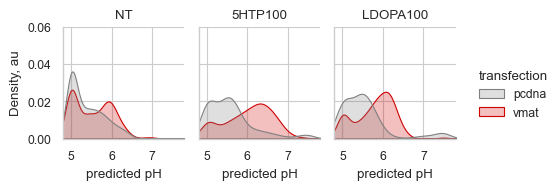

c:\Users\med\mambaforge\envs\napari-flim-phasor-env\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


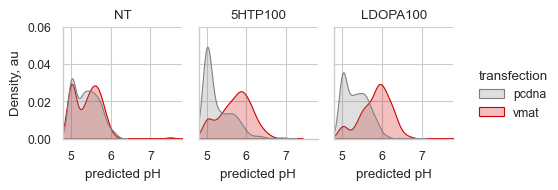

In [134]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
sns.set_context("paper")

# Define the desired order of 'treatment_group' columns
treatment_group_order = ['NT', '5HTP100', 'LDOPA100']

# Define a custom color palette
custom_palette = {"pcdna": "#808080", "vmat": "#D00000"}

# Filter for two different cell types
sampled_data_1 = sampled_data[sampled_data['cells'] == 'cl1']
sampled_data_2 = sampled_data[sampled_data['cells'] == 'cl2']


# Check if there's data in the filtered datasets
if not sampled_data_1.empty:
    # Plot for the first subset (e.g., CellType1)
    h1 = sns.displot(
        sampled_data_1, hue="transfection", x="predicted_pH_values", col="base_treatment",
        kind="kde", height=2, aspect=0.8, fill=True, col_wrap=3, col_order=treatment_group_order,
        palette=custom_palette  # Apply custom colors
    )
    # Set axis labels and titles for the first plot
    h1.set_axis_labels("predicted pH", "Density, au")
    h1.set_titles("{col_name}")
    h1.set(xlim=(4.8, 7.8), ylim=(0, 0.06))  # Apply global y-axis limits
    plt.show()
else:
    print("No data available for CellType1")

# Check if there's data in the second filtered dataset
if not sampled_data_2.empty:
    # Plot for the second subset (e.g., CellType2)
    h2 = sns.displot(
        sampled_data_2, hue="transfection", x="predicted_pH_values", col="base_treatment",
        kind="kde", height=2, aspect=0.8, fill=True, col_wrap=3, col_order=treatment_group_order,
        palette=custom_palette  # Apply custom colors
    )
    # Set axis labels and titles for the second plot
    h2.set_axis_labels("predicted pH", "Density, au")
    h2.set_titles("{col_name}")
    h2.set(xlim=(4.8, 7.8), ylim=(0, 0.06))  # Apply global y-axis limits
    plt.show()
else:
    print("No data available for CellType2")
#4.8, 7.8 limits for pH


In [14]:

# Function to calculate percentage of data in each range
def calculate_percentage_in_ranges(data, tau_col, ranges, group_cols):
    """
    Calculate the percentage of data points that fall within specified ranges.
    
    Args:
    - data: DataFrame containing the data.
    - tau_col: The column that contains the 'mean_tau' values.
    - ranges: List of tuples with ranges (e.g., [(800, 1000), (1100, 1200), ...]).
    - group_cols: The columns to group by (e.g., ['cells', 'transfection', 'treatment']).
    
    Returns:
    - DataFrame with the percentage of data points in each range for each group.
    """
    total_counts = data.groupby(group_cols)[tau_col].count().reset_index(name='total_count')

    results = []

    for range_name, (low, high) in ranges.items():
        # Filter data within the range
        in_range = data[(data[tau_col] >= low) & (data[tau_col] <= high)]
        
        # Count the number of data points in this range
        range_counts = in_range.groupby(group_cols)[tau_col].count().reset_index(name=f'{range_name}_count')
        
        # Merge with the total counts
        merged = pd.merge(total_counts, range_counts, on=group_cols, how='left')
        
        # Calculate the percentage
        merged[f'{range_name}_percentage'] = (merged[f'{range_name}_count'] / merged['total_count']) * 100
        
        # Append the results
        results.append(merged[[*group_cols, f'{range_name}_percentage']])

    # Merge all range results together
    final_result = results[0]
    for result in results[1:]:
        final_result = pd.merge(final_result, result, on=group_cols, how='left')

    return final_result

# Define the ranges
range1_50_55 = (800, 1000)
range2_60 = (1100, 1200)
range3_65 = (1200, 1400)
range4_70_75 = (1300, 1800)

# Define the ranges with names
ranges = {
    'range1_50_55': range1_50_55,
    'range2_60': range2_60,
    'range3_65': range3_65,
    'range4_70_75': range4_70_75
}




  Condition    Time  range1_50_55_percentage  range2_60_percentage  \
0       cl1  24-28h                     54.0                   4.0   
1       cl1    4-6h                     73.0                   7.0   
2       cl2  24-28h                     62.0                  10.0   
3       cl2    4-6h                     74.0                   6.0   
4        wt  24-28h                     66.0                   4.0   
5        wt    4-6h                     70.0                   1.0   

   range3_65_percentage  range4_70_75_percentage  
0                  24.0                     17.0  
1                   1.0                      NaN  
2                  14.0                      4.0  
3                   1.0                      NaN  
4                   8.0                      9.0  
5                   2.0                      NaN  


In [17]:
def calculate_percentage_in_ranges(data, tau_col, ranges, group_cols):
    total_counts = data.groupby(group_cols)[tau_col].count().reset_index(name='total_count')
    results = []

    for range_name, (low, high) in ranges.items():
        in_range = data[(data[tau_col] >= low) & (data[tau_col] <= high)]
        range_counts = in_range.groupby(group_cols)[tau_col].count().reset_index(name=f'{range_name}_count')

        merged = pd.merge(total_counts, range_counts, on=group_cols, how='left')
        merged[f'{range_name}_count'] = merged[f'{range_name}_count'].fillna(0)  # fill NaNs

        merged[f'{range_name}_percentage'] = (merged[f'{range_name}_count'] / merged['total_count']) * 100
        results.append(merged[[*group_cols, f'{range_name}_percentage']])

    # Merge all range results together
    final_result = results[0]
    for result in results[1:]:
        final_result = pd.merge(final_result, result, on=group_cols, how='left')

    return final_result


In [25]:
# Define the ranges
range1_50_55 = (400, 1000)
range2_60 = (1001, 1200)
range3_65 = (1201, 1400)
range4_70_75 = (1401, 2500)

# Define the ranges with names
ranges = {
    'range1_50_55': range1_50_55,
    'range2_60': range2_60,
    'range3_65': range3_65,
    'range4_70_75': range4_70_75
}


# Group by 'cells', 'transfection', and 'treatment'
group_cols = ['Condition', 'Time']

# Calculate the percentages for each range
percentage_results = calculate_percentage_in_ranges(combined_df, 'tau', ranges, group_cols)

# Display the result
print(percentage_results)

  Condition    Time  range1_50_55_percentage  range2_60_percentage  \
0       cl1  24-28h                53.299492             18.274112   
1       cl1    4-6h                70.763501             27.560521   
2       cl2  24-28h                59.322034             24.152542   
3       cl2    4-6h                79.672131             18.360656   
4        wt  24-28h                74.911661             15.194346   
5        wt    4-6h                72.670807             25.155280   

   range3_65_percentage  range4_70_75_percentage  
0             21.827411                 6.598985  
1              1.489758                 0.000000  
2             13.983051                 2.542373  
3              0.983607                 0.000000  
4              6.713781                 3.180212  
5              1.863354                 0.000000  


In [26]:
# Save the DataFrame to Excel with the new column
output_path = r"C:\Users\med\Desktop\Thesis\ranges_oy.xlsx"
percentage_results.to_excel(output_path, index=False)